### CD4 T-cell Pseudobulk Differential Expression Analysis using DESeq2
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Age-associated pseudobulk differential expression*

#### Aim
This notebook performs age-associated differential expression analysis on CD4 T-cell pseudobulk count matrices using DESeq2.

Pseudobulk samples were generated at the donor-by-cell-type level. For each CD4 subset, gene expression was modelled as a function of age while adjusting for sex and batch.

*Note: This notebook performs differential expression testing only. Gene set enrichment analysis was performed separately using the DESeq2 output files.*

In [5]:
library(DESeq2)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb



In [ ]:
# Load gene-by-sample pseudobulk count matrix
counts <- read.csv(
  "/scratch/user/s4575250/BIOX7014_Thesis/write/04_DEG/PICA_Batch001-Batch007/CD4_pseudobulk_counts_gene_by_sample.csv",
  row.names = 1,
  check.names = FALSE
)

# Load matching pseudobulk sample metadata
meta <- read.csv(
  "/scratch/user/s4575250/BIOX7014_Thesis/write/04_DEG/PICA_Batch001-Batch007/CD4_pseudobulk_metadata.csv",
  row.names = 1,
  check.names = FALSE
)

In [ ]:
# Match metadata order to the pseudobulk count matrix
meta <- meta[colnames(counts), ]

stopifnot(all(colnames(counts) == rownames(meta)))

In [ ]:
# Convert metadata variables into appropriate types for DESeq2 modelling
meta$age <- as.numeric(meta$age)
meta$sex <- factor(meta$sex)
meta$batch <- factor(meta$batch)
meta$cell_type <- factor(meta$cell_type)

# quick check
table(meta$cell_type)
summary(meta$age)
table(meta$sex)
table(meta$batch)


    CD4 cytoT CD4 naive/Tcm       CD4 Tem           Tfh          Treg 
           86           128           127           126           127 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.050   4.460   7.690   8.405  12.975  17.030 


Female   Male 
   248    346 


20240530_WGS_20240530_sc_PICA0001-PICA0007 
                                        26 
20240918_WGS_20240924_sc_PICA0008-PICA0032 
                                       104 
20241106_WGS_20241106_sc_PICA0033-PICA0069 
                                       111 
20250114_WGS_20241218_sc_PICA0071-PICA0097 
                                       112 
20250324_WGS_20250324_sc_PICA0098-PICA0118 
                                        75 
20250612_WGS_20250612_sc_PICA0119-PICA0146 
                                        95 
20250814_WGS_20250814_sc_PICA0147-PICA0173 
                                        71 

## DESeq2

In [ ]:
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4", showWarnings = FALSE)

# Define function to run DESeq2 separately for each subset
run_deseq_celltype <- function(ct) {
  
  # Select pseudobulk samples belonging to subset
  samples <- rownames(meta)[meta$cell_type == ct]
  
  counts_sub <- counts[, samples, drop = FALSE]
  meta_sub <- meta[samples, , drop = FALSE]
  
  # Skip subsets with insufficient donor-level samples
  if (ncol(counts_sub) < 6) {
    message("Skipping ", ct, ": too few samples")
    return(NULL)
  }
  
  # Remove lowly expressed genes before model fitting
  keep_genes <- rowSums(counts_sub >= 10) >= 3
  counts_sub <- counts_sub[keep_genes, ]
  
  # Construct DESeq2 dataset with batch and sex adjustment
  dds <- DESeqDataSetFromMatrix(
    countData = round(as.matrix(counts_sub)),
    colData = meta_sub,
    design = ~ batch + sex + age
  )
  
  # Fit negative binomial model
  dds <- DESeq(dds)
  
  # Extract age-associated differential expression results
  res <- results(dds, name = "age")
  res <- as.data.frame(res)
  res$gene <- rownames(res)
  res <- res[order(res$padj), ]
  
  # Create safe cell-type name for file export
  safe_ct <- gsub("[ /+]", "_", ct)
  
  # Save full DESeq2 result table
  write.csv(
    res,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/DESeq2_age_", safe_ct, ".csv"),
    row.names = FALSE
  )
  
  sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
  
  # Save significant age-associated genes
  write.csv(
    sig,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/DESeq2_age_", safe_ct, "_significant.csv"),
    row.names = FALSE
  )
  
  return(res)
}

# Run DESeq2 analysis across all subsets
celltypes <- levels(meta$cell_type)

all_deg <- list()

for (ct in celltypes) {
  all_deg[[ct]] <- run_deseq_celltype(ct)
}

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an 

In [ ]:
# Create summary table of significant age-associated genes per subset
summary_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) {
    summary_list[[ct]] <- data.frame(
      cell_type = ct,
      n_sig = NA,
      n_up_with_age = NA,
      n_down_with_age = NA
    )
  } else {
    sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
    
    summary_list[[ct]] <- data.frame(
      cell_type = ct,
      n_sig = nrow(sig),
      n_up_with_age = sum(sig$log2FoldChange > 0),
      n_down_with_age = sum(sig$log2FoldChange < 0)
    )
  }
}

# Combine and save DEG summary table
deg_summary <- do.call(rbind, summary_list)

write.csv(
  deg_summary,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/DESeq2_age_summary.csv",
  row.names = FALSE
)

deg_summary

,cell_type,n_sig,n_up_with_age,n_down_with_age
,<chr>,<int>,<int>,<int>
CD4 cytoT,CD4 cytoT,566,311,255
CD4 naive/Tcm,CD4 naive/Tcm,7528,3818,3710
CD4 Tem,CD4 Tem,5534,3033,2501
Tfh,Tfh,4018,2271,1747
Treg,Treg,3160,1736,1424


In [11]:
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/top_genes", showWarnings = FALSE, recursive = TRUE)
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/volcano_plots", showWarnings = FALSE, recursive = TRUE)
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/heatmaps", showWarnings = FALSE, recursive = TRUE)

In [ ]:
# Export top 20 age-associated genes for each subset
for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top20 <- head(res, 20)
  
  safe_ct <- gsub("[ /+]", "_", ct)
  
  write.csv(
    top20,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/top_genes/top20_DEGs_", safe_ct, ".csv"),
    row.names = FALSE
  )
}

# View top genes for key subsets
head(all_deg[["CD4 naive/Tcm"]][order(all_deg[["CD4 naive/Tcm"]]$padj), ], 20)
head(all_deg[["CD4 Tem"]][order(all_deg[["CD4 Tem"]]$padj), ], 20)
head(all_deg[["Tfh"]][order(all_deg[["Tfh"]]$padj), ], 20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DISC1FP1,127.950798,0.18032222,0.008682039,20.76957,8.158278e-96,1.586867e-91,DISC1FP1
KIF21A,143.286200,0.15666668,0.008396365,18.65887,1.069689e-77,1.040326e-73,KIF21A
SORCS3,48.332618,0.20901762,0.012526264,16.68635,1.647420e-62,1.068132e-58,SORCS3
RADX,180.856601,0.17258494,0.010637729,16.22385,3.420497e-59,1.663302e-55,RADX
LINC01684,100.124378,0.18044908,0.011639788,15.50278,3.321933e-54,1.292298e-50,LINC01684
CBX5,1355.371553,0.02380871,0.001603527,14.84772,7.197969e-50,2.333461e-46,CBX5
ZNF662,16.732989,0.15807541,0.010907495,14.49237,1.353965e-47,3.762281e-44,ZNF662
ERVH48-1,91.661262,-0.16522872,0.011605161,-14.23752,5.359487e-46,1.303092e-42,ERVH48-1
LONRF3,70.716152,0.19182106,0.013615394,14.08854,4.466821e-45,9.653792e-42,LONRF3


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ADAM23,41.640682,0.35905722,0.017176408,20.90409,4.914507e-97,8.162505e-93,ADAM23
CFH,57.951738,0.28948148,0.015325676,18.88866,1.413897e-79,1.174170e-75,CFH
FER,120.967792,0.12380616,0.006809929,18.18024,7.400474e-74,4.097149e-70,FER
PRKN,144.694926,0.14623773,0.008080015,18.09869,3.263092e-73,1.354918e-69,PRKN
RADX,79.011371,0.20573319,0.011650076,17.65939,8.617140e-70,2.862442e-66,RADX
TRPC1,39.971522,0.13627713,0.007808531,17.45234,3.304215e-68,8.050483e-65,TRPC1
MID2,42.825114,0.14081590,0.008069297,17.45083,3.392942e-68,8.050483e-65,MID2
PPP2R2B,132.319610,0.18773092,0.010818936,17.35207,1.902676e-67,3.950192e-64,PPP2R2B
DISC1FP1,39.612047,0.16473741,0.009906055,16.62997,4.227924e-62,7.802400e-59,DISC1FP1


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PCSK5,35.809987,0.18156227,0.011174751,16.24755,2.324863e-59,3.291076e-55,PCSK5
NR3C2,169.148241,0.16557512,0.010222639,16.19691,5.302908e-59,3.753398e-55,NR3C2
SPART,61.416844,0.15912191,0.009842508,16.16681,8.646773e-59,4.080124e-55,SPART
PRKN,91.154207,0.13650109,0.008736666,15.62393,5.002297e-55,1.770313e-51,PRKN
CPQ,116.627033,0.11215787,0.007433840,15.08747,1.957964e-51,5.543389e-48,CPQ
RADX,28.513428,0.18716369,0.012538331,14.92732,2.188865e-50,5.164261e-47,RADX
RNF157,65.763055,0.10820130,0.007375728,14.66991,1.004714e-48,2.031818e-45,RNF157
MID2,24.200216,0.12925264,0.008920028,14.49016,1.398137e-47,2.474004e-44,MID2
IGF1R,54.107966,0.12658843,0.008836706,14.32530,1.520772e-46,2.392005e-43,IGF1R


In [ ]:
# Combine top 20 age-associated genes from each subset into a single table
combined_top_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top20 <- head(res, 20)
  top20$cell_type <- ct
  
  combined_top_list[[ct]] <- top20
}

combined_top_degs <- do.call(rbind, combined_top_list)

write.csv(
  combined_top_degs,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/CD4_combined_top20_DEGs_by_celltype.csv",
  row.names = FALSE
)

combined_top_degs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,cell_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CD4 cytoT.NR3C2,12.426237,0.22263491,0.027114556,8.210900,2.195368e-16,2.593168e-12,NR3C2,CD4 cytoT
CD4 cytoT.CFH,3.419592,0.31308730,0.040549986,7.721021,1.154013e-14,6.815603e-11,CFH,CD4 cytoT
CD4 cytoT.SVIL,13.197465,0.10975282,0.015591484,7.039280,1.932358e-12,7.608339e-09,SVIL,CD4 cytoT
CD4 cytoT.RHOC,25.407216,0.09580056,0.014838843,6.456067,1.074593e-10,3.173272e-07,RHOC,CD4 cytoT
CD4 cytoT.AKT3,41.561992,0.11354051,0.018100035,6.272944,3.542845e-10,8.369617e-07,AKT3,CD4 cytoT
CD4 cytoT.CNTLN,2.604169,-0.23349754,0.038616806,-6.046527,1.480018e-09,2.913663e-06,CNTLN,CD4 cytoT
CD4 cytoT.SSBP2,20.783578,0.09443031,0.015744976,5.997488,2.003926e-09,2.958796e-06,SSBP2,CD4 cytoT
CD4 cytoT.RADX,4.041267,0.18295580,0.030419689,6.014388,1.805681e-09,2.958796e-06,RADX,CD4 cytoT
CD4 cytoT.ABLIM1,115.705971,-0.04983804,0.008450196,-5.897856,3.682561e-09,4.833156e-06,ABLIM1,CD4 cytoT


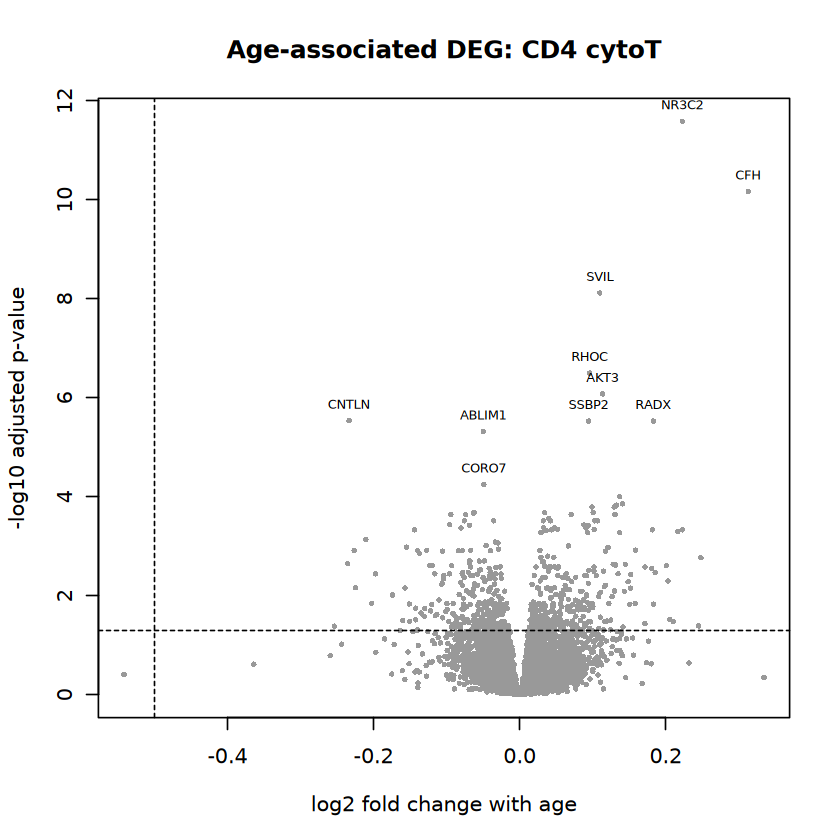

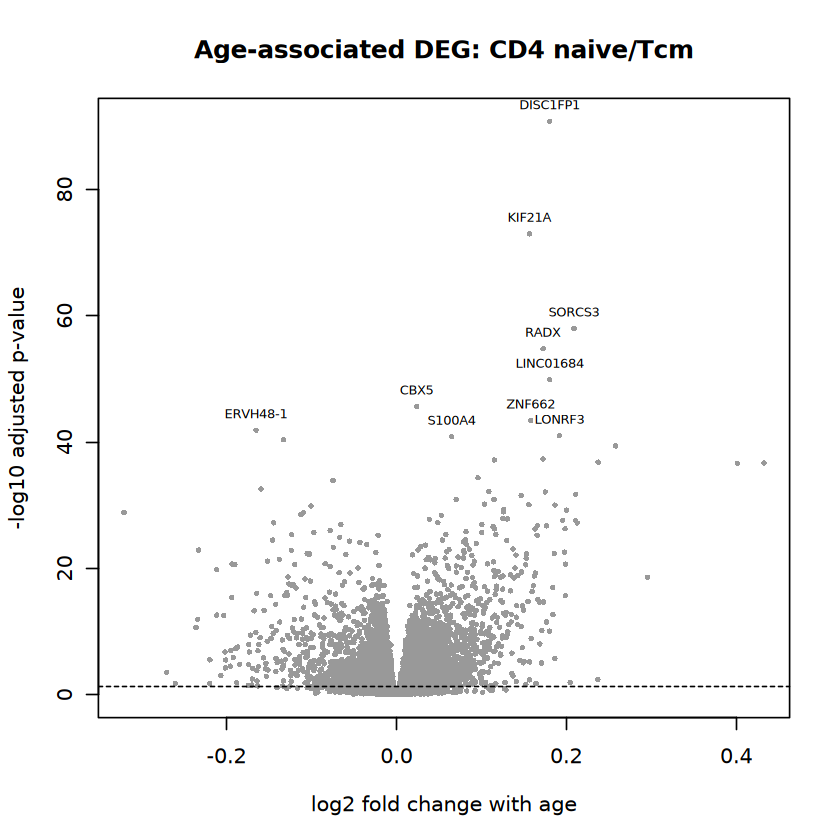

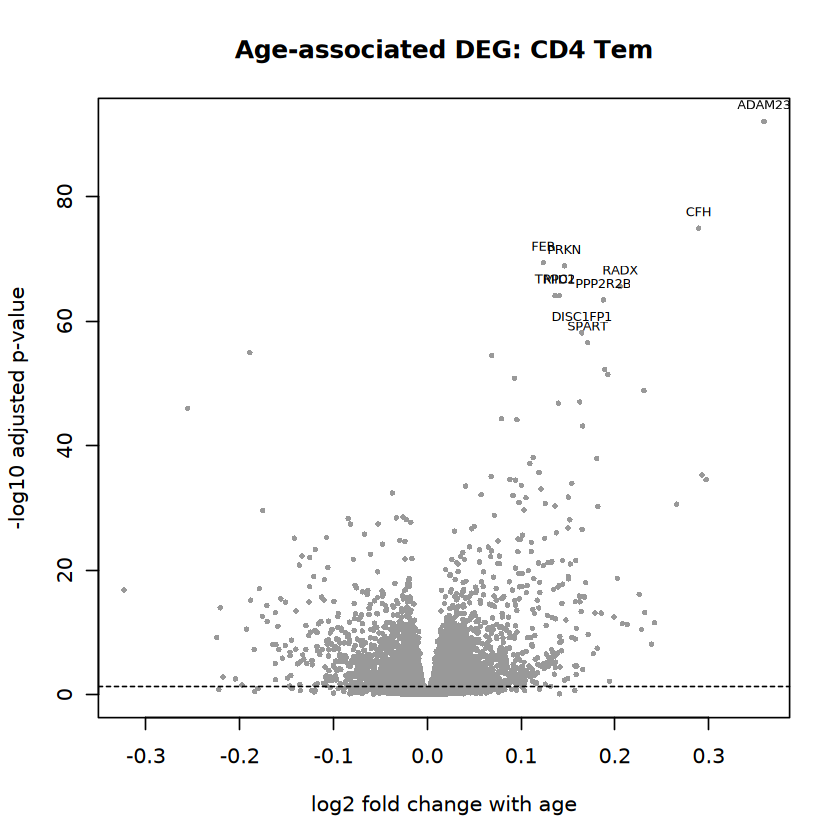

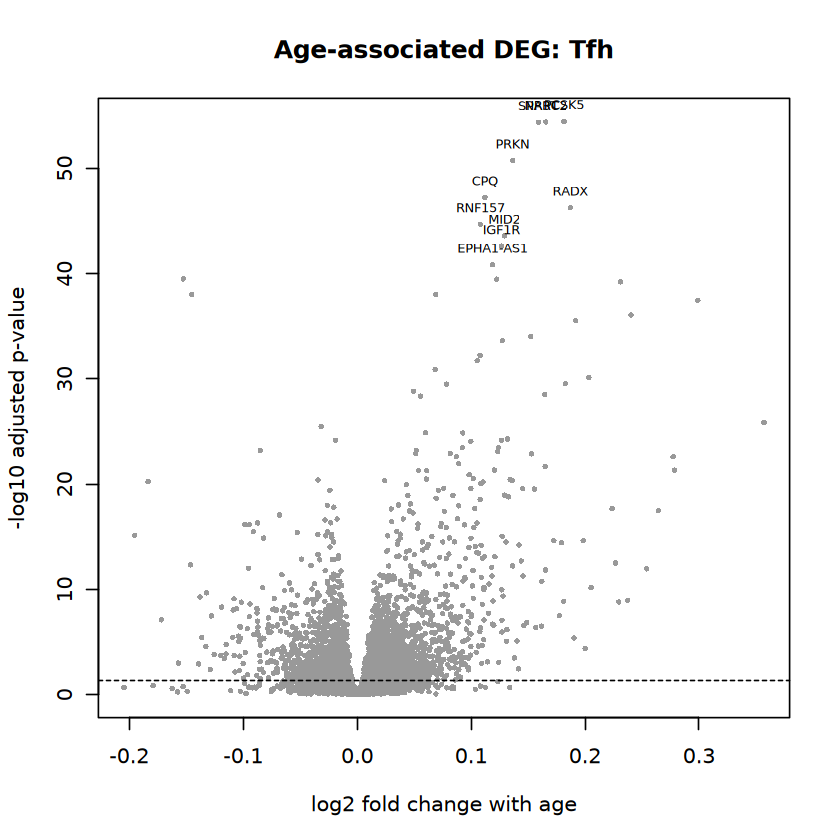

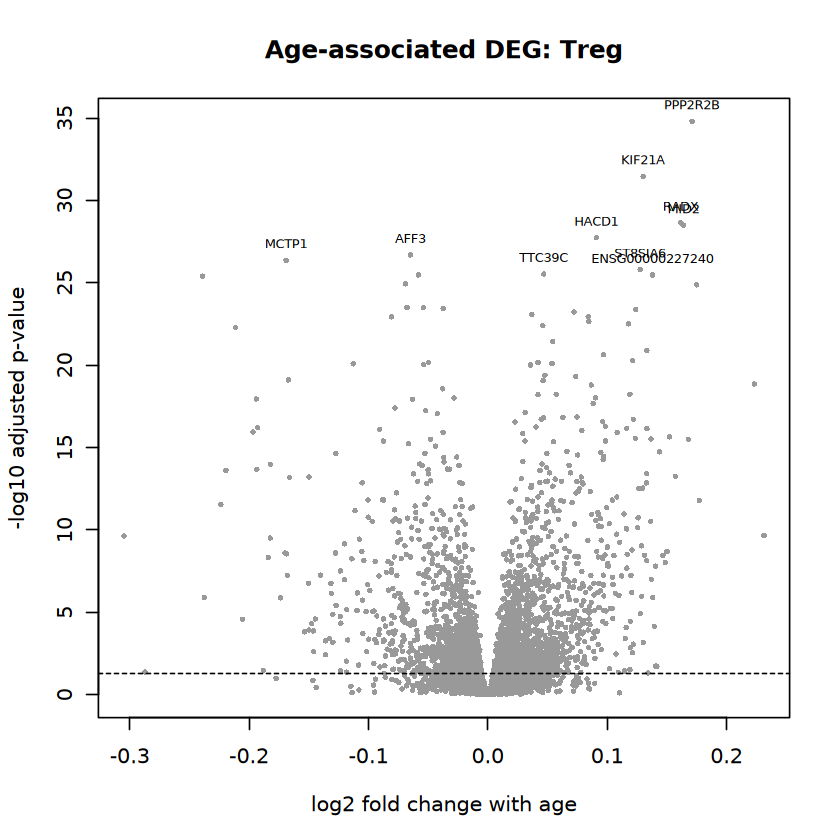

In [ ]:
# Define function to visualise age-associated differential expression results
plot_volcano <- function(res, celltype_name, padj_cutoff = 0.05, lfc_cutoff = 0.5, save_plot = TRUE) {
  
  # Remove genes without adjusted p-values
  res <- res[!is.na(res$padj), ]
  
  # Calculate transformed significance and label genes passing thresholds
  res$neg_log10_padj <- -log10(res$padj)
  res$significant <- res$padj < padj_cutoff & abs(res$log2FoldChange) > lfc_cutoff
  
  # Select top genes for labelling
  top_genes <- head(res[order(res$padj), ], 10)
  
  # Display volcano plot
  plot(
    res$log2FoldChange,
    res$neg_log10_padj,
    pch = 16,
    cex = 0.5,
    col = ifelse(res$significant, "red", "grey60"),
    xlab = "log2 fold change with age",
    ylab = "-log10 adjusted p-value",
    main = paste("Age-associated DEG:", celltype_name)
  )
  
  # Add fold-change and adjusted p-value cutoffs
  abline(v = c(-lfc_cutoff, lfc_cutoff), lty = 2, col = "black")
  abline(h = -log10(padj_cutoff), lty = 2, col = "black")
  
  # Label top-ranked genes
  text(
    top_genes$log2FoldChange,
    top_genes$neg_log10_padj,
    labels = top_genes$gene,
    pos = 3,
    cex = 0.6
  )
  
  # Save
  if (save_plot) {
    
    safe_ct <- gsub("[ /+]", "_", celltype_name)
    
    png(
      paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/volcano_plots/volcano_", safe_ct, ".png"),
      width = 1800,
      height = 1500,
      res = 200
    )
    
    plot(
      res$log2FoldChange,
      res$neg_log10_padj,
      pch = 16,
      cex = 0.5,
      col = ifelse(res$significant, "red", "grey60"),
      xlab = "log2 fold change with age",
      ylab = "-log10 adjusted p-value",
      main = paste("Age-associated DEG:", celltype_name)
    )
    
    abline(v = c(-lfc_cutoff, lfc_cutoff), lty = 2, col = "black")
    abline(h = -log10(padj_cutoff), lty = 2, col = "black")
    
    text(
      top_genes$log2FoldChange,
      top_genes$neg_log10_padj,
      labels = top_genes$gene,
      pos = 3,
      cex = 0.6
    )
    
    dev.off()
  }
}

# Generate volcano plots for each subset
for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  plot_volcano(res, ct)
}

Making heatmap for: CD4 cytoT

converting counts to integer mode



  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

Making heatmap for: CD4 naive/Tcm

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scal

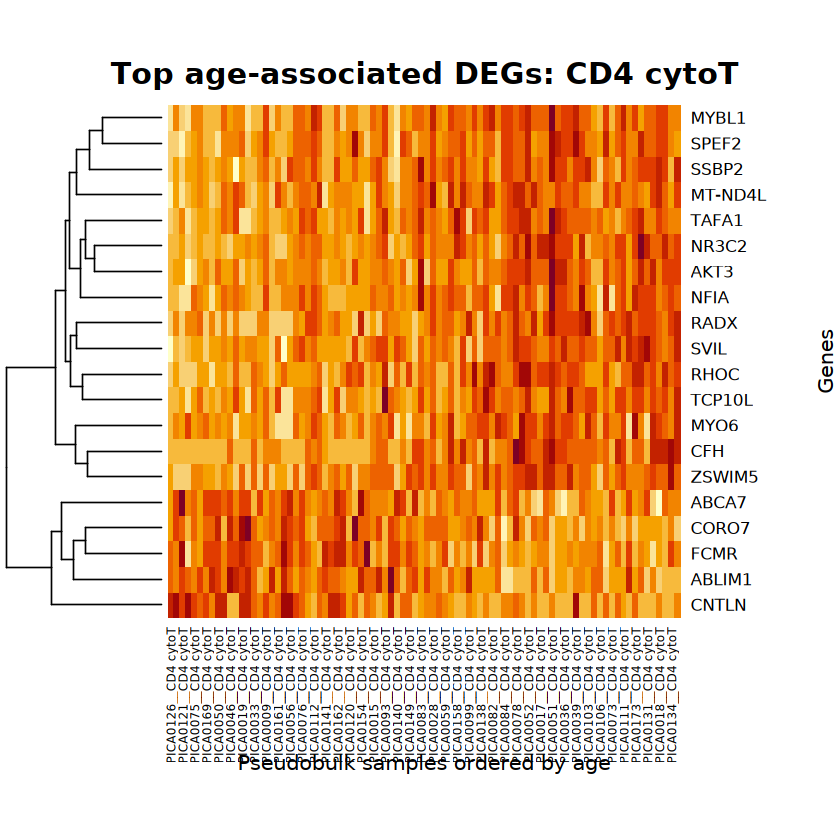

Making heatmap for: CD4 Tem

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



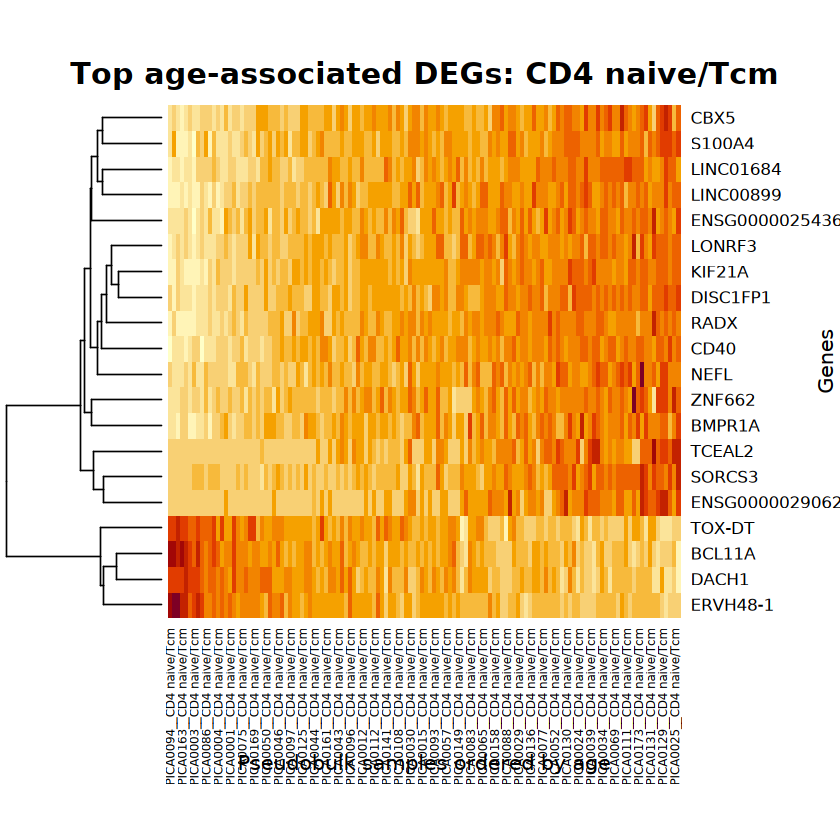

Making heatmap for: Tfh

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



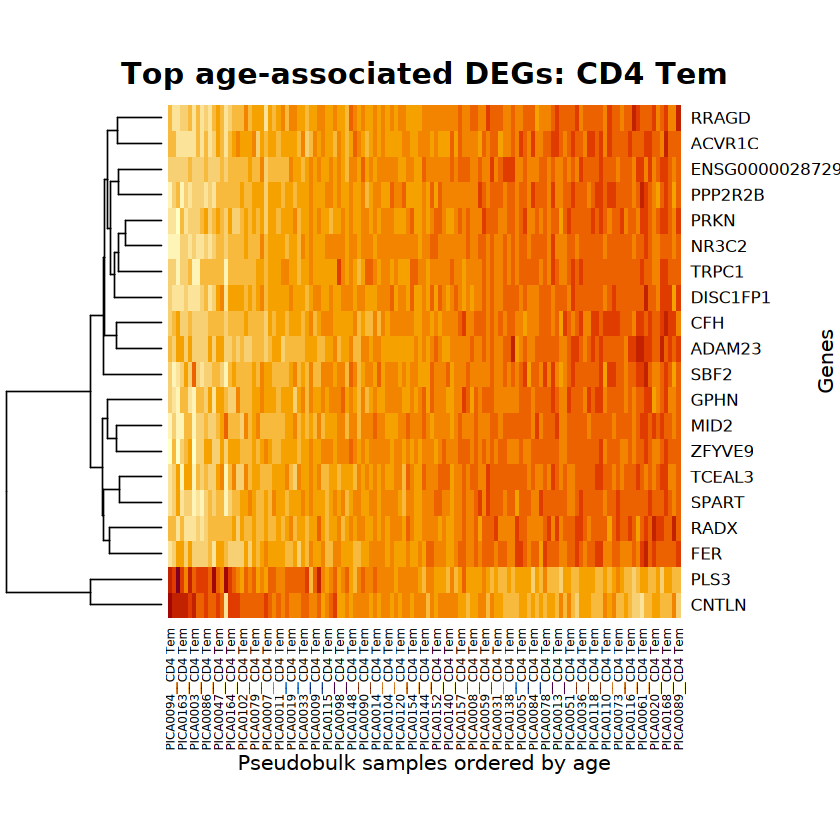

Making heatmap for: Treg

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



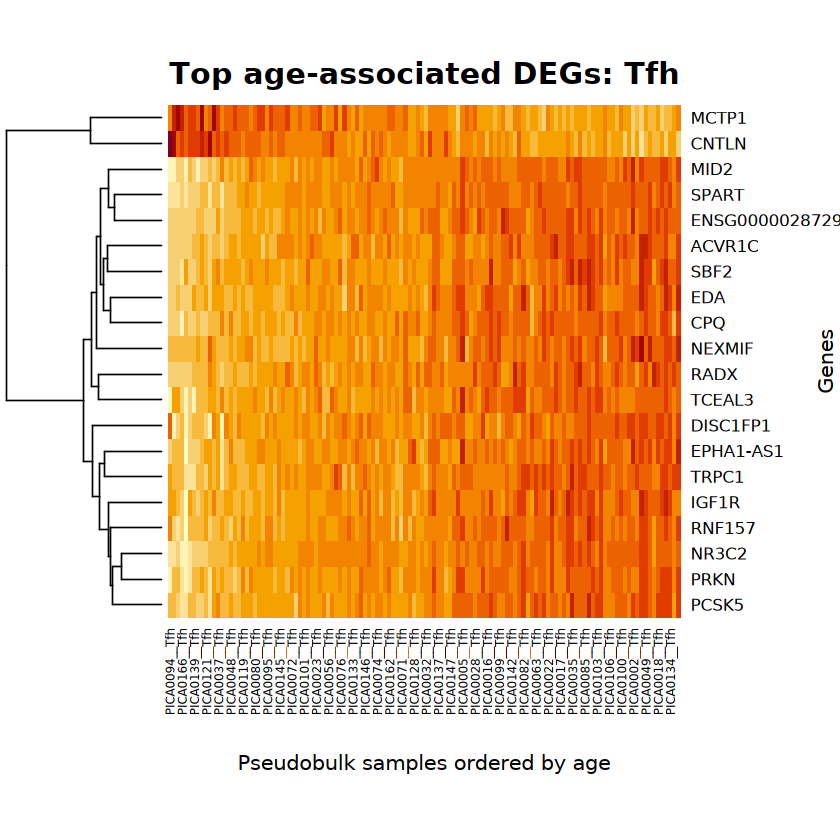

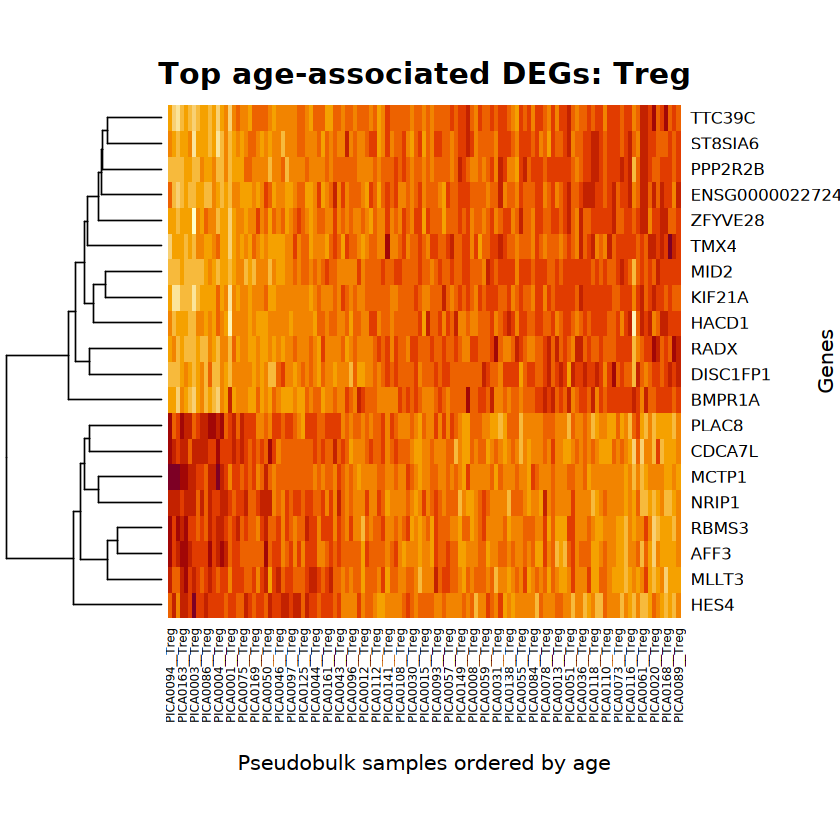

In [ ]:
# Define function to visualise top age-associated genes across pseudobulk samples
make_heatmap <- function(ct, top_n = 20, save_plot = TRUE) {
  
  message("Making heatmap for: ", ct)
  
  # Extract DESeq2 results for selected cell type
  res <- all_deg[[ct]]
  
  if (is.null(res)) {
    message("No DEG result for: ", ct)
    return(NULL)
  }
  
  # Select top-ranked genes by adjusted p-value
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top_genes <- head(res$gene, top_n)
  
  # Extract pseudobulk counts and metadata for selected cell type
  samples <- rownames(meta)[meta$cell_type == ct]
  
  counts_sub <- counts[, samples, drop = FALSE]
  meta_sub <- meta[samples, , drop = FALSE]
  
  # Apply the same low-expression filter used during DESeq2 modelling
  keep_genes <- rowSums(counts_sub >= 10) >= 3
  counts_sub <- counts_sub[keep_genes, ]
  
  # Retain top genes available in the filtered count matrix
  top_genes <- top_genes[top_genes %in% rownames(counts_sub)]
  
  if (length(top_genes) < 2) {
    message("Too few top genes available for heatmap: ", ct)
    return(NULL)
  }
  
  # Build DESeq2 object for variance-stabilising transformation
  dds <- DESeqDataSetFromMatrix(
    countData = round(as.matrix(counts_sub)),
    colData = meta_sub,
    design = ~ batch + sex + age
  )
  
  vsd <- vst(dds, blind = TRUE)
  
  # Extract transformed expression for top genes
  mat <- assay(vsd)[top_genes, , drop = FALSE]
  
  # z-score per gene
  mat_scaled <- t(scale(t(mat)))
  
  # order samples by age
  sample_order <- order(meta_sub$age)
  mat_scaled <- mat_scaled[, sample_order, drop = FALSE]
  
  # Display heatmap
  heatmap(
    mat_scaled,
    Colv = NA,
    scale = "none",
    margins = c(8, 8),
    main = paste("Top age-associated DEGs:", ct),
    xlab = "Pseudobulk samples ordered by age",
    ylab = "Genes"
  )
  
  # Save
  if (save_plot) {
    
    safe_ct <- gsub("[ /+]", "_", ct)
    
    png(
      paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/heatmaps/heatmap_top", top_n, "_", safe_ct, ".png"),
      width = 2000,
      height = 1600,
      res = 200
    )
    
    heatmap(
      mat_scaled,
      Colv = NA,
      scale = "none",
      margins = c(8, 8),
      main = paste("Top age-associated DEGs:", ct),
      xlab = "Pseudobulk samples ordered by age",
      ylab = "Genes"
    )
    
    dev.off()
  }
}

# Generate heatmaps for each subset
for (ct in names(all_deg)) {
  make_heatmap(ct, top_n = 20)
}

In [ ]:
# Summarise Marker Gene Differential Expression
# Define marker genes used for biological interpretation of subset states
marker_genes <- c(
  # Naive / central memory
  "CCR7", "SELL", "IL7R", "LTB", "TCF7",

  # Effector / cytotoxic CD4
  "GZMB", "GZMK", "PRF1", "NKG7", "GNLY",

  # Tfh
  "CXCR5", "PDCD1", "ICOS", "BCL6", "IL21",

  # Treg
  "FOXP3", "IL2RA", "CTLA4", "IKZF2",

  # Interferon response
  "ISG15", "IFIT1", "IFIT3", "MX1",

  # Proliferation
  "MKI67", "TOP2A"           
)

# Extract DESeq2 results for selected marker genes across subsets
marker_summary_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  sub <- res[res$gene %in% marker_genes, ]
  sub$cell_type <- ct
  
  marker_summary_list[[ct]] <- sub
}

marker_summary <- do.call(rbind, marker_summary_list)

write.csv(
  marker_summary,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4/CD4_marker_gene_DEG_summary.csv",
  row.names = FALSE
)

marker_summary

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,cell_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CD4 cytoT.CCR7,22.811711,-0.143928856,0.030100302,-4.7816417,1.738694e-06,4.667603e-04,CCR7,CD4 cytoT
CD4 cytoT.LTB,279.956062,-0.067037202,0.016351026,-4.0998775,4.133689e-05,3.906171e-03,LTB,CD4 cytoT
CD4 cytoT.GNLY,879.161052,0.129943879,0.033893837,3.8338497,1.261532e-04,8.054713e-03,GNLY,CD4 cytoT
CD4 cytoT.ICOS,65.553820,-0.068924526,0.018120788,-3.8036165,1.425989e-04,8.772803e-03,ICOS,CD4 cytoT
CD4 cytoT.CTLA4,52.201262,-0.076717262,0.021293811,-3.6027962,3.148123e-04,1.481499e-02,CTLA4,CD4 cytoT
CD4 cytoT.NKG7,938.612259,0.054964956,0.015907811,3.4552181,5.498478e-04,2.048834e-02,NKG7,CD4 cytoT
CD4 cytoT.GZMK,409.650289,-0.078808713,0.023501074,-3.3534090,7.982266e-04,2.641079e-02,GZMK,CD4 cytoT
CD4 cytoT.MX1,32.435378,-0.075827498,0.023566027,-3.2176615,1.292403e-03,3.469514e-02,MX1,CD4 cytoT
CD4 cytoT.TOP2A,5.099959,-0.087201188,0.028023471,-3.1117198,1.860010e-03,4.307928e-02,TOP2A,CD4 cytoT
